# Model Ensembling & Blending - PS-S06E09: Electric Vehicle Purchases

This notebook loads Out-Of-Fold (OOF) and Test probability predictions generated by individual model notebooks (`XGBoost`, `LightGBM`, `CatBoost`, etc.), evaluates model correlations, and optimizes ensemble blending weights to produce the final competition submission.

## 1. Setup & Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_model_visualizer import ModelVisualizer

setup = ExperimentSetup(model_name='Ensemble')
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Warnings suppressed.


## 2. Load Predictions

In [2]:
oof_files = []
test_files = []

if setup.running_in_kaggle():
    pred_dirs = ["/kaggle/input/notebooks/stephentarter/ps-s06e09-*/predictions"]
else:
    pred_dirs = ["predictions"]

EXCLUDE_PREFIXES = ("blending", "stacking", "ensemble")

def _is_base_model_file(path):
    name = os.path.basename(path)
    return not name.startswith(EXCLUDE_PREFIXES)

for p_dir in pred_dirs:
    oof_files.extend(glob.glob(f"{p_dir}/*_oof_probs.csv"))
    test_files.extend(glob.glob(f"{p_dir}/*_test_probs.csv"))

oof_files  = sorted(f for f in oof_files  if _is_base_model_file(f))
test_files = sorted(f for f in test_files if _is_base_model_file(f))

print(f"Found {len(oof_files)} OOF files and {len(test_files)} Test files.")
for f in oof_files:
    print(" -", os.path.basename(f))

Found 3 OOF files and 3 Test files.
 - catboost_oof_probs.csv
 - lgb_oof_probs.csv
 - xgb_oof_probs.csv


In [3]:
oof_dict = {}
test_dict = {}
y_true = None

for oof_file in oof_files:
    prefix = oof_file.replace('_oof_probs.csv', '')
    test_file = oof_file.replace('_oof_probs.csv', '_test_probs.csv')
    
    oof_df = pd.read_csv(oof_file)
    test_df = pd.read_csv(test_file)
    
    if y_true is None:
        y_true = oof_df['target'].values
        
    oof_dict[prefix] = oof_df['prob_1'].values
    test_dict[prefix] = test_df['prob_1'].values
    
    score = roc_auc_score(y_true, oof_dict[prefix])
    print(f'Model: {prefix:<15} | OOF ROC AUC: {score:.6f}')

Model: predictions/catboost | OOF ROC AUC: 0.941849
Model: predictions/lgb | OOF ROC AUC: 0.942371
Model: predictions/xgb | OOF ROC AUC: 0.942342


## 3. Prediction Correlation Matrix

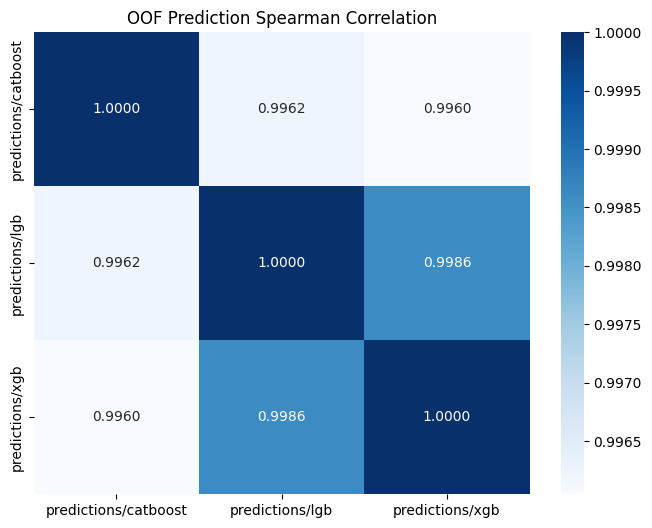

In [4]:
if oof_dict:
    oof_preds_df = pd.DataFrame(oof_dict)
    corr = oof_preds_df.corr(method='spearman')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.4f', cmap='Blues')
    plt.title('OOF Prediction Spearman Correlation')
    plt.show()

## 4. Optimize Ensemble Weights

In [5]:
if oof_dict:
    models_list = list(oof_dict.keys())
    matrix = np.column_stack([oof_dict[m] for m in models_list])
    test_matrix = np.column_stack([test_dict[m] for m in models_list])
    
    def loss_func(weights):
        weights = weights / np.sum(weights)
        blend = np.dot(matrix, weights)
        return -roc_auc_score(y_true, blend)
    
    init_weights = np.ones(len(models_list)) / len(models_list)
    bounds = [(0, 1) for _ in range(len(models_list))]
    
    res = minimize(loss_func, init_weights, method='SLSQP', bounds=bounds)
    opt_weights = res.x / np.sum(res.x)
    
    print('\nOptimized Ensemble Weights:')
    for m, w in zip(models_list, opt_weights):
        print(f'  - {m:<15}: {w:.4f}')
        
    blend_oof = np.dot(matrix, opt_weights)
    blend_auc = roc_auc_score(y_true, blend_oof)
    print(f'\n==========================================')
    print(f'Optimized Ensemble OOF ROC AUC: {blend_auc:.6f}')
    print(f'==========================================')
    
    blend_test = np.dot(test_matrix, opt_weights)


Optimized Ensemble Weights:
  - predictions/catboost: 0.3333
  - predictions/lgb: 0.3333
  - predictions/xgb: 0.3333

Optimized Ensemble OOF ROC AUC: 0.942308


## 5. Generate Submission File

In [6]:
if 'blend_test' in locals():
    submission_df = setup.read_dataset('submission')
    submission_df[TARGET] = blend_test
    submission_df.to_csv('submission.csv', index=False)
    print('Saved final ensemble submission.csv successfully!')

Saved final ensemble submission.csv successfully!
